In [24]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:98%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

**<font size="6" color="red"> ch01. NLTK 자연어처리 패키지 </font>**

```
자연어처리 : 텍스트 전처리, 단어의 빈도수 측정, 문서유사도 측정, 연관분석, 딥러닝,
            워드임베딩, 어휘데이터 베이스 사용, 감정분석, 분류분석 

```
# 1. NLTK 패키지
- 텍스트 전처리, 단어빈도수 측정 : 토큰화(문장, 어절, 형태소 나누기), 정규표현식을이용한 불용어처리, 어간추출, 
- 품사태깅 : 단어별 품사를 식별 
```
pip install nltk==3.7
```


In [2]:
import nltk

In [3]:
#말뭉치들 다운로드 받을 폴더(book 선택후 다운로드)
#c:/nltk_data 또는 d:/nltk_data 또는 c:/User/내컴퓨터이름/nltk_data 또는 c:/User/내컴퓨터이름/anaconda3/nltk_data
nltk.download()

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

In [4]:
#말뭉치 리스트
nltk.corpus.gutenberg.fileids()

['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

In [5]:
emma = nltk.corpus.gutenberg.raw('austen-emma.txt')
print(emma[:100])
print(type(emma))
print('글자수:', len(emma))

[Emma by Jane Austen 1816]

VOLUME I

CHAPTER I


Emma Woodhouse, handsome, clever, and rich, with a
<class 'str'>
글자수: 887071


In [6]:
#sent_tokenize() 문장 단위로 쪼갠 list 반환
from nltk.tokenize import sent_tokenize
sent_tokens= sent_tokenize(emma)
print('문장수:', len(sent_tokens))
print('두번째장:', sent_tokens[1])

문장수: 7456
두번째장: She was the youngest of the two daughters of a most affectionate,
indulgent father; and had, in consequence of her sister's marriage,
been mistress of his house from a very early period.


In [7]:
# word_tokenize() : 단어 단위로 쪼갠 list 반환
from nltk.tokenize import word_tokenize
print(word_tokenize(sent_tokens[1]))

['She', 'was', 'the', 'youngest', 'of', 'the', 'two', 'daughters', 'of', 'a', 'most', 'affectionate', ',', 'indulgent', 'father', ';', 'and', 'had', ',', 'in', 'consequence', 'of', 'her', 'sister', "'s", 'marriage', ',', 'been', 'mistress', 'of', 'his', 'house', 'from', 'a', 'very', 'early', 'period', '.']


In [8]:
# RegexpTokenizer클래스
from nltk.tokenize import RegexpTokenizer
ret = RegexpTokenizer('\d+') #[0-9]+   #숫자만
digits = ret.tokenize(emma)
print(digits)
print()
ret1 = RegexpTokenizer('\w+') #[a-zA-Z0-9]+   #문자 다
words=ret1.tokenize(sent_tokens[0])
print(words)
print()
ret2=RegexpTokenizer('[a-zA-Z]{3,}') #알파벳만
words2=ret2.tokenize(sent_tokens[0])
print(words2)

['1816', '8', '23', '28', '28', '24', '7', '10', '000', '10', '000', '26']

['Emma', 'by', 'Jane', 'Austen', '1816', 'VOLUME', 'I', 'CHAPTER', 'I', 'Emma', 'Woodhouse', 'handsome', 'clever', 'and', 'rich', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of', 'existence', 'and', 'had', 'lived', 'nearly', 'twenty', 'one', 'years', 'in', 'the', 'world', 'with', 'very', 'little', 'to', 'distress', 'or', 'vex', 'her']

['Emma', 'Jane', 'Austen', 'VOLUME', 'CHAPTER', 'Emma', 'Woodhouse', 'handsome', 'clever', 'and', 'rich', 'with', 'comfortable', 'home', 'and', 'happy', 'disposition', 'seemed', 'unite', 'some', 'the', 'best', 'blessings', 'existence', 'and', 'had', 'lived', 'nearly', 'twenty', 'one', 'years', 'the', 'world', 'with', 'very', 'little', 'distress', 'vex', 'her']


# 2. 형태소(의미가 있는 가장 작은 다위) 분석
- 자연어 처리의 기본 : 형태소 분석과 품사태깅 - 어간추출(Stemmer), 품사태깅(pos_tag)

In [9]:
words=['sending','cooking','files','lives','crying','dying']
#어간 추출1 :PorterStemmer
from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer
pst=PorterStemmer()
pst.stem(words[5])

'die'

In [10]:
[ pst.stem(word) for word in words]

['send', 'cook', 'file', 'live', 'cri', 'die']

In [11]:
#[ pst.stem(word) for word in words2]

In [12]:
# 어간 추출2 : LancasterStemmer
lst =LancasterStemmer()
[lst.stem(word) for word in words]

['send', 'cook', 'fil', 'liv', 'cry', 'dying']

In [13]:
# 어간 추출3 : RegexpStemmer
rst =RegexpStemmer('ing')
[rst.stem(word) for word in words]

['send', 'cook', 'files', 'lives', 'cry', 'dy']

# 3. 품사태깅
https://dbrang.tistory.com/1139 

In [14]:
from nltk.tag import pos_tag


In [15]:
tagged_list =pos_tag(word_tokenize(sent_tokens[0]))
print('품사태깅 결과:',tagged_list)

품사태깅 결과: [('[', 'NNS'), ('Emma', 'NNP'), ('by', 'IN'), ('Jane', 'NNP'), ('Austen', 'NNP'), ('1816', 'CD'), (']', 'NNP'), ('VOLUME', 'NNP'), ('I', 'PRP'), ('CHAPTER', 'VBP'), ('I', 'PRP'), ('Emma', 'NNP'), ('Woodhouse', 'NNP'), (',', ','), ('handsome', 'NN'), (',', ','), ('clever', 'NN'), (',', ','), ('and', 'CC'), ('rich', 'JJ'), (',', ','), ('with', 'IN'), ('a', 'DT'), ('comfortable', 'JJ'), ('home', 'NN'), ('and', 'CC'), ('happy', 'JJ'), ('disposition', 'NN'), (',', ','), ('seemed', 'VBD'), ('to', 'TO'), ('unite', 'VB'), ('some', 'DT'), ('of', 'IN'), ('the', 'DT'), ('best', 'JJS'), ('blessings', 'NNS'), ('of', 'IN'), ('existence', 'NN'), (';', ':'), ('and', 'CC'), ('had', 'VBD'), ('lived', 'VBN'), ('nearly', 'RB'), ('twenty-one', 'CD'), ('years', 'NNS'), ('in', 'IN'), ('the', 'DT'), ('world', 'NN'), ('with', 'IN'), ('very', 'RB'), ('little', 'JJ'), ('to', 'TO'), ('distress', 'VB'), ('or', 'CC'), ('vex', 'VB'), ('her', 'PRP'), ('.', '.')]


In [16]:
#명사만 추출 : NN, NNP, NNS, NNPS
nouns_list=[]
for word, tag in tagged_list:
    if (tag=='NN')|(tag=='NNS')|(tag=='NNP')|(tag=='NNPS'):
#   if tag in['NN','NNS','NNP','NNPS']   
        nouns_list.append(word)
print(nouns_list)

['[', 'Emma', 'Jane', 'Austen', ']', 'VOLUME', 'Emma', 'Woodhouse', 'handsome', 'clever', 'home', 'disposition', 'blessings', 'existence', 'years', 'world']


In [17]:
nouns_list1=[ word for word, tag in tagged_list if tag in['NN','NNS','NNP','NNPS'] ]
print(nouns_list1)

['[', 'Emma', 'Jane', 'Austen', ']', 'VOLUME', 'Emma', 'Woodhouse', 'handsome', 'clever', 'home', 'disposition', 'blessings', 'existence', 'years', 'world']


## QUIZ. emma 소설안에서
1. 특수문자가 들어가지 않은 3글자 이상의 단어(RegexpTokenizer)만 추출해서 품사태깅(pos_tag)하세요
2. 'Emma', 'emma' 단어가 몇번 등장했는지, 품사태깅이 어떤 품사들(set)로 되어 있는지 모두출력하시오.
3. 내가 원하는 품사(명사 : NN, NNS, NNP, NNPS)만 뽑아 등장하는 명사의 종류 갯수 출력하시오.

In [18]:
import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.tag import pos_tag
emma = nltk.corpus.gutenberg.raw('austen-emma.txt')
ret=RegexpTokenizer('\w{3,}')
words =ret.tokenize(emma)
print('단어수 ;', len(words))
tagged_list = pos_tag(words)

단어수 ; 123877


In [19]:
#1. 특수문자가 들어가지 않은 3글자 이상의 단어(RegexpTokenizer)만 추출해서 품사태깅(pos_tag)하세요
print(tagged_list[:10])

[('Emma', 'NNP'), ('Jane', 'NNP'), ('Austen', 'NNP'), ('1816', 'CD'), ('VOLUME', 'NNP'), ('CHAPTER', 'NNP'), ('Emma', 'NNP'), ('Woodhouse', 'NNP'), ('handsome', 'VBD'), ('clever', 'NN')]


In [20]:
#2. 'Emma', 'emma' 단어가 몇번 등장했는지, 품사태깅이 어떤 품사들(set)로 되어 있는지 모두출력하시오.
nouns_list=[ (word, tag) for word, tag in tagged_list if word in['emma','Emma']]
print("'Emma', 'emma' 등장수:",len(nouns_list))
set(nouns_list)
emma_tag_list=[tag for word, tag in set(nouns_list)]
print('Emma 품사태깅 종류:',emma_tag_list)

'Emma', 'emma' 등장수: 865
Emma 품사태깅 종류: ['VBN', 'NN', 'NNPS', 'VB', 'VBD', 'VBP', 'NNP', 'JJ', 'NNS', 'RB']


In [32]:
#Emma를 NNP는 몇번 태깅되었는지, NNS는 몇번 태깅되었는지 등 각 품사별 태깅이 몇번 되었는지(series이용)
import pandas as pd
pos_cnt=pd.Series([0]*len(emma_tag_list),index=emma_tag_list)
for word, tag in tagged_list:
    if word == 'Emma':
        pos_cnt[tag] +=1
pos_cnt.sort_values(ascending=False)

NNP     838
NN        7
VB        5
VBP       4
JJ        4
NNPS      2
NNS       2
VBN       1
VBD       1
RB        1
dtype: int64

In [43]:
pos_cnt = dict()
for word, tag in tagged_list:
    if word == 'Emma':
        if tag in pos_cnt:
            pos_cnt[tag]+=1
        else:
            pos_cnt[tag]=1
print(pos_cnt)
sorted(pos_cnt.items(),key = lambda x:x[1], reverse=True)

{'NNP': 838, 'VBP': 4, 'JJ': 4, 'VB': 5, 'NNS': 2, 'RB': 1, 'NN': 7, 'NNPS': 2, 'VBN': 1, 'VBD': 1}


[('NNP', 838),
 ('NN', 7),
 ('VB', 5),
 ('VBP', 4),
 ('JJ', 4),
 ('NNS', 2),
 ('NNPS', 2),
 ('RB', 1),
 ('VBN', 1),
 ('VBD', 1)]

In [21]:
# 3. 내가 원하는 품사(명사 : NN, NNS, NNP, NNPS)만 뽑아 등장하는 명사의 종류 갯수 출력하시오.

In [49]:
nouns_list=[ word for word, tag in tagged_list if tag in['NN','NNS','NNP','NNPS'] ]

In [23]:
print('명사 갯수:',len(set(nouns_list)))

명사 갯수: 4165


# 4. 최빈 단어 시각화

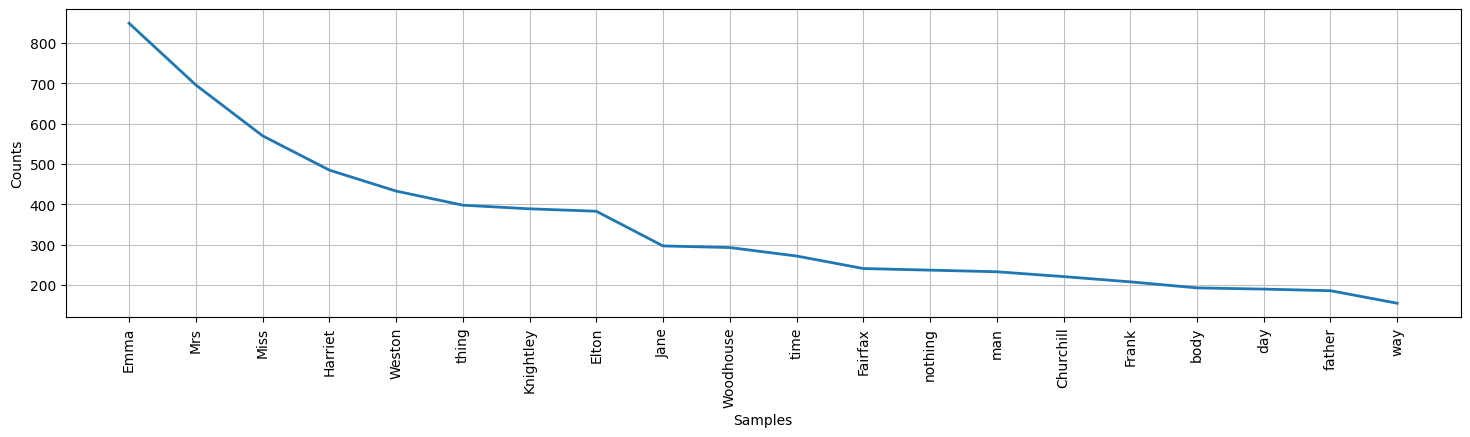

In [53]:
import matplotlib.pyplot as plt 
from nltk import Text
#Text : 단어리스트와 관련된 빈도분석이나 단어검색을 쉽게 처리할 수 있는 클래스
emma_text=Text(nouns_list)
plt.figure(figsize=(18,4))
emma_text.plot(20)
plt.show()

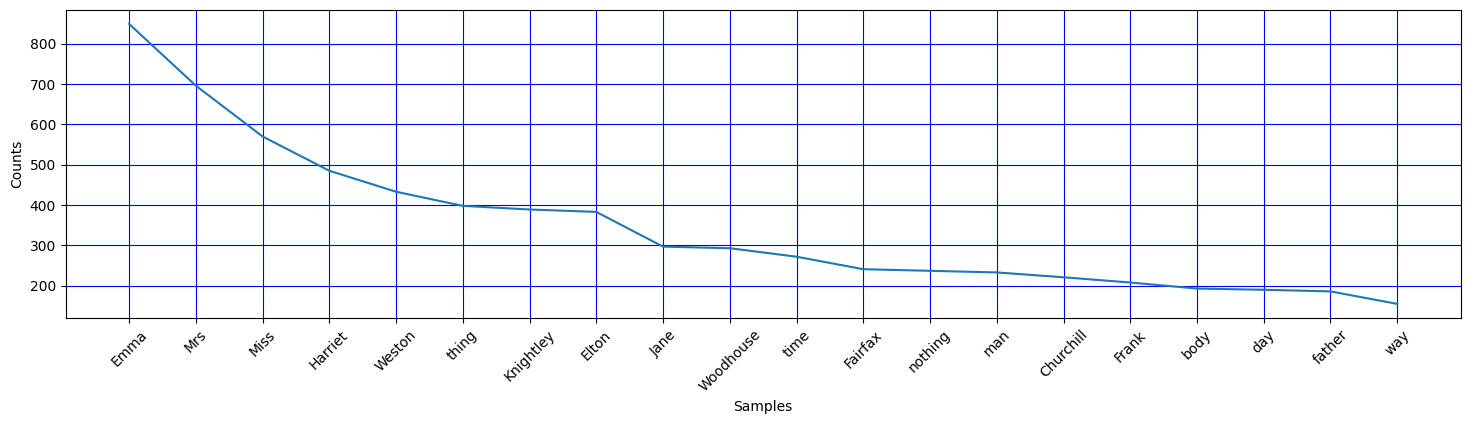

In [66]:
freqDist=emma_text.vocab()
most_common =freqDist.most_common(20) # 상위 20개
most_common
xlabel= [ word for word, count in most_common]
yvalue= [ count for word, count in most_common]
plt.figure(figsize=(18,4))
plt.plot(xlabel,yvalue, marker=None)
plt.xticks(rotation=45)
plt.xlabel('Samples')
plt.ylabel('Counts')
plt.grid(color='blue')
plt.show()

In [67]:
emma_text.count('Emma')

849

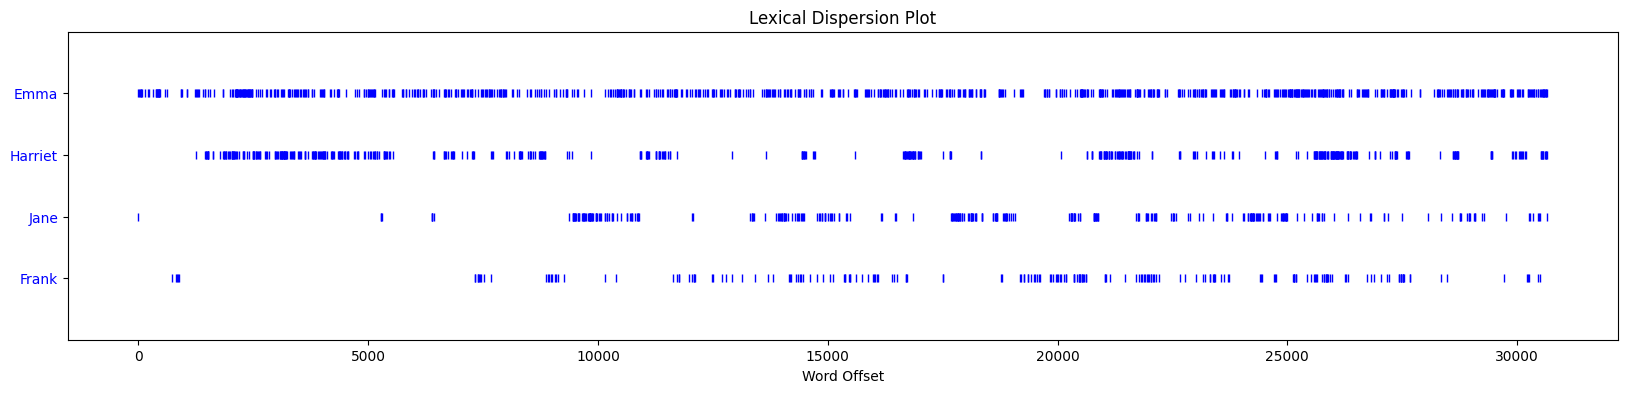

In [74]:
# Emma, Harriet, Jane, Frank emma소설 전체에서 어디에 등장하는지
plt.figure(figsize=(20,4))
emma_text.dispersion_plot(['Emma','Harriet','Jane','Frank'])

In [80]:
from nltk import FreqDist
tags = ['NNP','NNPS']
name_list=[word for word, tag in tagged_list if tag in tags]
name_count=FreqDist(name_list)
name_count

FreqDist({'Emma': 840, 'Mrs': 696, 'Miss': 569, 'Harriet': 484, 'Weston': 433, 'Knightley': 389, 'Elton': 382, 'Jane': 295, 'Woodhouse': 293, 'Fairfax': 241, ...})

In [82]:
for name, count in name_count.items():
    if count > 150:
        print(name,':',count)

Emma : 840
Jane : 295
Woodhouse : 293
Miss : 569
Weston : 433
Mrs : 696
Hartfield : 155
Knightley : 389
Elton : 382
Churchill : 221
Frank : 208
Harriet : 484
Fairfax : 241


In [86]:
name_count_s=pd.Series(name_count)
name_count_s.sort_values(ascending=False, inplace=True)
name_count_s[name_count_s>150]

Emma         840
Mrs          696
Miss         569
Harriet      484
Weston       433
Knightley    389
Elton        382
Jane         295
Woodhouse    293
Fairfax      241
Churchill    221
Frank        208
Hartfield    155
dtype: int64